Explore region behavior around sleep oscillating events

In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
#import regions as rg
import ISRUtilities as isru
import xarray as xr
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
def _regionPETH(session,regs=None,when=None,bin=0.025,lim_oscill=None,n_bins=None,lim_isa=None):

    # load data
    R = fma.regions.regions(session,states='sws',events='InfraSlowRhythm/infraslowaval',phases=when)
    regs = R.ids if regs is None else np.asarray(regs)[np.isin(regs,R.ids)]
    isa = R.eventIntervals('slownr')
    events, is_coupled, is_isa = isru.loadHpcPfcEvents(session,coupl=True,delta='ripples',isa=isa)
    epochs = [e for e in list(R.phases) if 'sleep' in e]
    epochs = xr.DataArray(np.concatenate([R.eventIntervals(e,epsilon=5) for e in epochs]), dims=['epoch','t'], coords={'epoch': epochs})
    events, epoch_idx = isru.epochIndex(events,epochs,duration=1200,nrem=R.eventIntervals('sws'))
    #off_on, on_off = isru.ISTransitions(isa,R.eventIntervals('slowavalnr'),[0.5,0.5])

    fr = R.firingRate(regs=regs,window=bin,step=1,norm=True)
    peth = {}
    for name in events:
        p, t, _ = fma.analysis.PETH(fr,events[name],limits=lim_oscill,n_bins=n_bins) # (events, time, regions)
        peth[name] = xr.DataArray(p,dims=['event','t','reg'],
            coords={'isa': ('event', is_isa[name]), 'coupl': ('event', is_coupled[name]), 'epoch': ('event', epoch_idx[name]), 't': t, 'reg': regs, 'base': R.basename, 'rat': int(R.rat)})

    # peth_isa = {}
    # p, t, _ = fma.analysis.PETH(fr,off_on,limits=lim_isa)
    # peth_isa['off_on'] = xr.DataArray(p,dims=['event','t','reg'],coords={'t': t, 'reg': regs, 'rat': int(R.rat)})
    # p, t, _ = fma.analysis.PETH(fr,on_off,limits=lim_isa)
    # peth_isa['on_off'] = xr.DataArray(p,dims=['event','t','reg'],coords={'t': t, 'reg': regs, 'rat': int(R.rat)})

    # peth_oscill = []
    # for name in names:
    #     peth_oscill.append([])
    #     _, t, p = fma.analysis.PETH(events[name],off_on,limits=lim_isa,n_bins=41,fast=True) # (time,)
    #     peth_oscill[-1].append(p)
    #     _, t, p = fma.analysis.PETH(events[name],on_off,limits=lim_isa,n_bins=41,fast=True) # (time,)
    #     peth_oscill[-1].append(p)
    # peth_oscill = xr.DataArray(peth_oscill,dims=['name','tran','t'],coords={'name': names, 'tran': ['off_on','on_off'], 't': t, 'rat': int(R.rat)})

    return peth, events #, peth_isa, peth_oscill

In [3]:
# test on one session
session = fma.data.readBatchFile(batch_file)[0][10]
print(session)
peth, events = _regionPETH(session,bin=0.01,lim_oscill=[-0.3,0.3],n_bins=201)

/mnt/hubel-data-139/perceval/Rat003_20231226/Rat003_20231226.xml


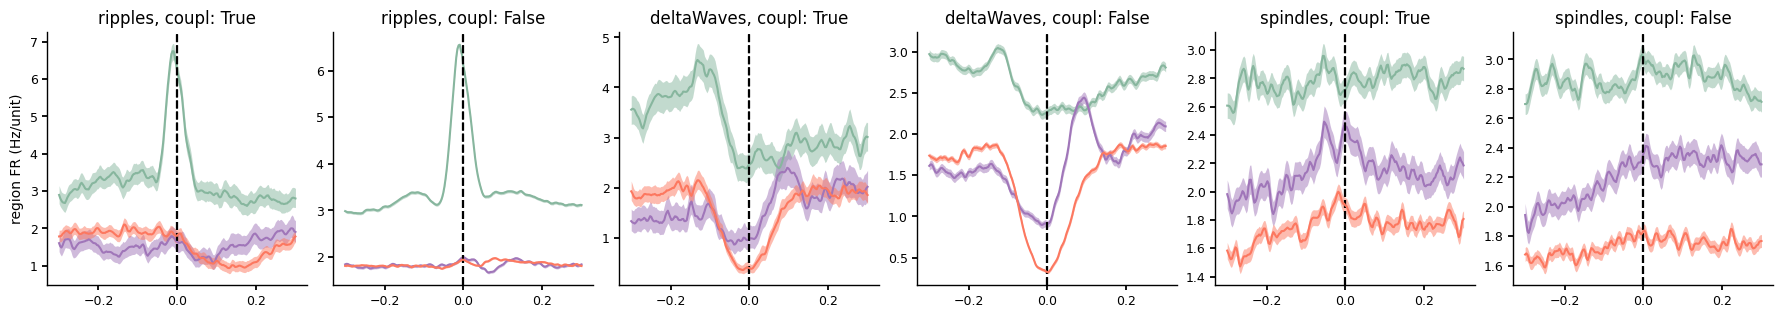

In [6]:
# see activity irrespective of ISA
fig, ax = fma.plotting.makeFigure(n=[1,len(peth)*2],size=[45,8])
for i, (name, fr_p) in enumerate(peth.items()):
        for coupl in [True,False]:
            for r in fr_p['reg'].values:
                ax[2*i+(not coupl)].set_title(f'{name}, coupl: {coupl}')
                ax[2*i+(not coupl)].axvline(0,color='k',ls='--')
                fma.plotting.semPlot(fr_p['t'],fr_p.where(fr_p.coupl==coupl, drop=True).sel(reg=r),color=isru.paperColors(r),ax=ax[2*i+(not coupl)])
ax[0].set(ylabel='region FR (Hz/unit)');

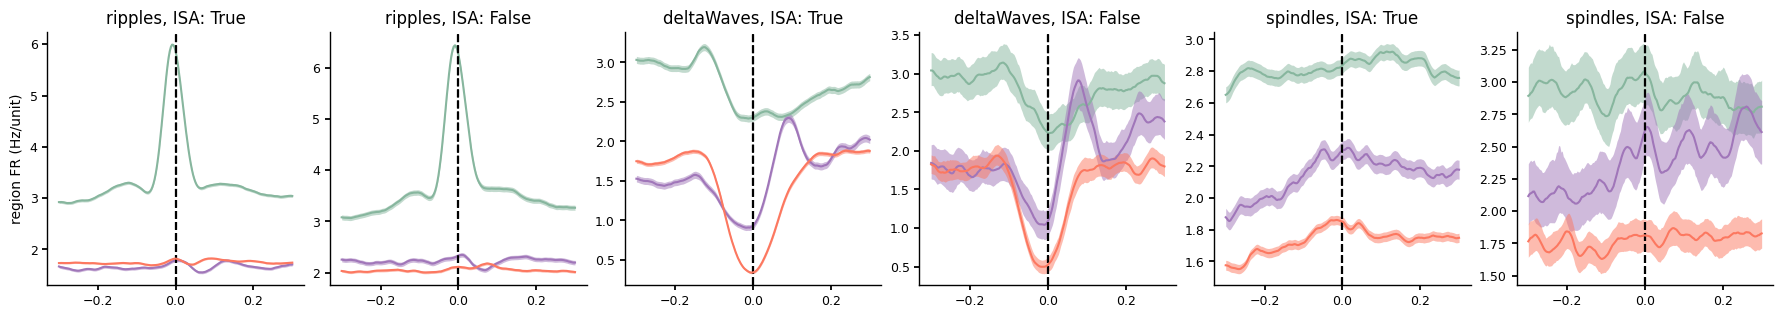

In [5]:
# see activity irrespective of coupling
fig, ax = fma.plotting.makeFigure(n=[1,len(peth)*2],size=[45,8])
for i, (name, fr_p) in enumerate(peth.items()):
        for isa in [True,False]:
            for r in fr_p['reg'].values:
                ax[2*i+(not isa)].set_title(f'{name}, ISA: {isa}')
                ax[2*i+(not isa)].axvline(0,color='k',ls='--')
                fma.plotting.semPlot(fr_p['t'],fr_p.where(fr_p.isa==isa, drop=True).sel(reg=r),color=isru.paperColors(r),ax=ax[2*i+(not isa)])
ax[0].set(ylabel='region FR (Hz/unit)');

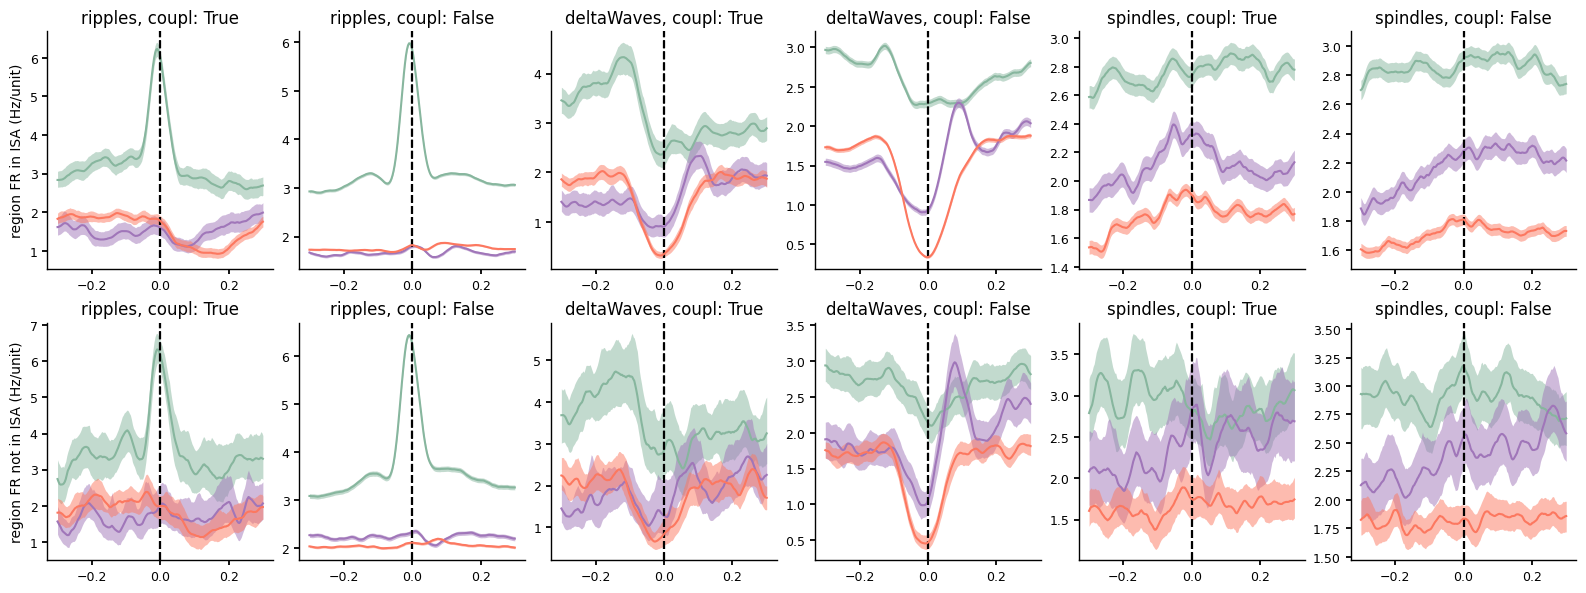

In [6]:
# see all combinations
fig, ax = fma.plotting.makeFigure(n=[2,len(peth)*2],size=[40,15])
for i, (name, fr_p) in enumerate(peth.items()):
    for isa in [True,False]:
        for coupl in [True,False]:
            for r in fr_p['reg'].values:
                ax[int(not isa),2*i+(not coupl)].set_title(f'{name}, coupl: {coupl}')
                ax[int(not isa),2*i+(not coupl)].axvline(0,color='k',ls='--')
                fma.plotting.semPlot(fr_p['t'],fr_p.where((fr_p.isa==isa) & (fr_p.coupl==coupl), drop=True).sel(reg=r),color=isru.paperColors(r),ax=ax[int(not isa),2*i+(not coupl)])
ax[0,0].set(ylabel='region FR in ISA (Hz/unit)'); ax[1,0].set(ylabel='region FR not in ISA (Hz/unit)');

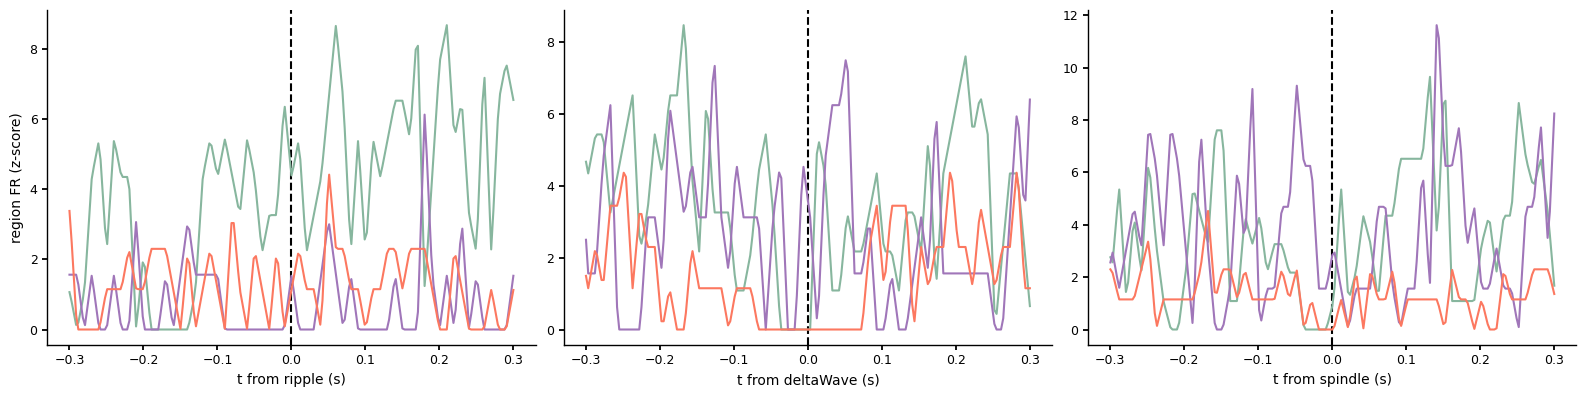

In [10]:
# see activity example
k = 35
fig, ax = fma.plotting.makeFigure(n=(1,len(peth)),size=(40,10))
for i, n in enumerate(peth):
    ax[i].set(xlabel=f't from {n[:-1]} (s)')
    ax[i].axvline(0,color='k',ls='--')
    fr_p = peth[n]
    for j, r in enumerate(fr_p['reg'].values):
        if r != 'th':
            ax[i].plot(fr_p.t,fr_p.sel(reg=r,event=k),color=isru.paperColors(r))
ax[0].set(ylabel='region FR (z-score)');

run batch

In [17]:
peth, events = fma.data.runBatch(batch_file,_regionPETH,kwargs={'bin': 0.01, 'lim_oscill': [-0.3,0.3],'n_bins': 351},parallel=True)


Starting Batch, 2026-07-03 11:36:50.217624 

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
/mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
/mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
/mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.sws not found.
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
only integer scalar arrays can be converted to a scalar index
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat

In [18]:
peth_cat = {name: xr.concat([d[name] for d in peth if d is not None],dim='event',join='outer') for name in peth[0]} # (session, region, threshold)
peth_avg = {name: xr.concat([d[name].mean(dim='event',skipna=True) for d in peth if d is not None],dim='rat',join='outer') for name in peth[0]} # (session, region, threshold)
peth_animal = {name: peth_cat[name].groupby('rat').mean(skipna=True) for name in peth_cat}
peth_coupl = {name: xr.concat([d[name].groupby('coupl').mean(skipna=True) for d in peth if d is not None],dim='rat',join='outer') for name in peth[0]} # (session, region, threshold)
peth_isa = {name: xr.concat([d[name].groupby('isa').mean(skipna=True) for d in peth if d is not None],dim='rat',join='outer') for name in peth[0]} # (session, region, threshold)
peth_epoch = {name: xr.concat([d[name].groupby('epoch').mean(skipna=True) for d in peth if d is not None],dim='rat',join='outer') for name in peth[0]} # (session, region, threshold)
peth_epoch_coupl = {name: xr.concat([d[name].groupby(('epoch','coupl')).mean(skipna=True) for d in peth if d is not None],dim='rat',join='outer') for name in peth[0]} # (session, region, threshold)

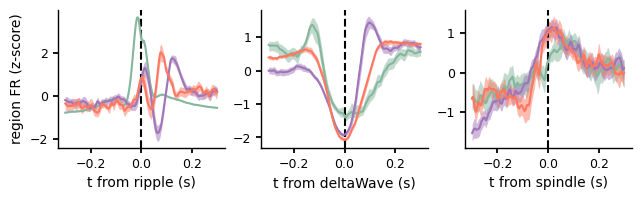

In [24]:
# see average PETHs
fig, ax = fma.plotting.makeFigure(n=(1,len(peth_avg)),size=(16,5))
for i, n in enumerate(peth_avg):
    ax[i].set(xlabel=f't from {n[:-1]} (s)')
    ax[i].axvline(0,color='k',ls='--')
    fr_p = peth_avg[n]
    for j, r in enumerate(fr_p['reg'].values):
        if r != 'th':
            fma.plotting.semPlot(fr_p.t,fr_p.sel(reg=r),zscore=2,color=isru.paperColors(r),ax=ax[i])
ax[0].set(ylabel='region FR (z-score)');
do_save and fma.plotting.saveFigure(fig,froot / 'oscill_peth',['png','svg'])

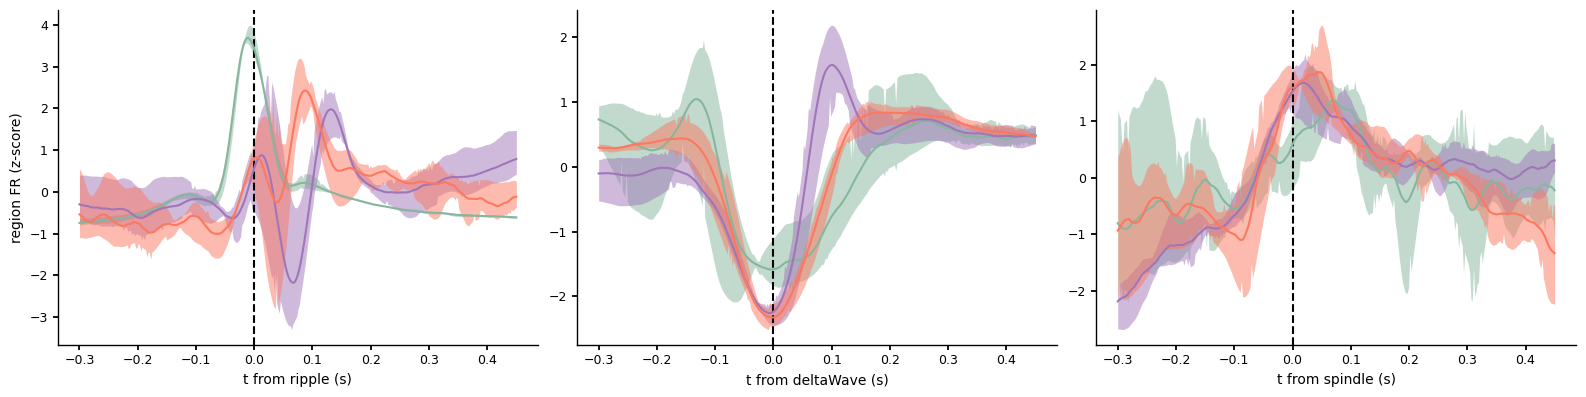

In [94]:
# see animal PETHs
fig, ax = fma.plotting.makeFigure(n=(1,len(peth_animal)),size=(40,10))
for i, n in enumerate(peth_animal):
    ax[i].set(xlabel=f't from {n[:-1]} (s)')
    ax[i].axvline(0,color='k',ls='--')
    fr_p = peth_animal[n]
    for j, r in enumerate(fr_p['reg'].values):
        if r != 'th':
            fma.plotting.semPlot(fr_p.t,fr_p.sel(reg=r),zscore=2,color=isru.paperColors(r),ax=ax[i])
ax[0].set(ylabel='region FR (z-score)');

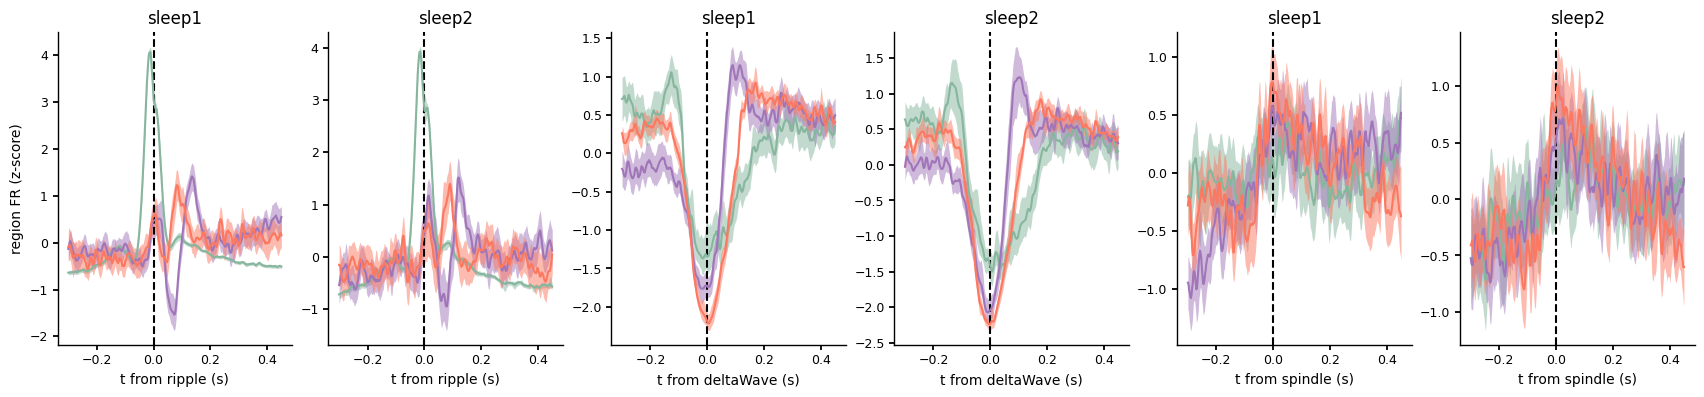

In [7]:
# see averages PETHs by epoch
fig, ax = fma.plotting.makeFigure(n=(1,2*len(peth_epoch)),size=(43,10))
for k, n in enumerate(peth_epoch):
    for j, c in enumerate([1,2]):
        i = 2*k + j
        ax[i].set(xlabel=f't from {n[:-1]} (s)',title=f'sleep{c}')
        ax[i].axvline(0,color='k',ls='--')
        fr_p = peth_epoch[n].sel(epoch=c)
        for r in fr_p['reg'].values:
            if r != 'th':
                fma.plotting.semPlot(fr_p.t,fr_p.sel(reg=r),zscore=2,color=isru.paperColors(r),ax=ax[i])
ax[0].set(ylabel='region FR (z-score)');

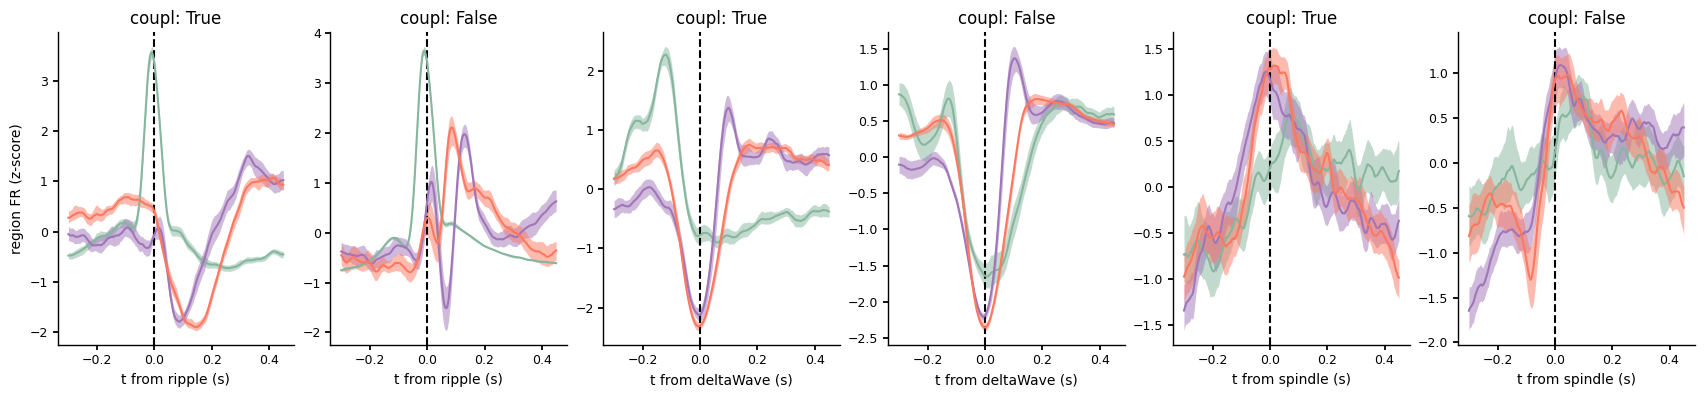

In [99]:
# see averages PETHs by coupling
fig, ax = fma.plotting.makeFigure(n=(1,2*len(peth_coupl)),size=(43,10))
for k, n in enumerate(peth_coupl):
    for j, c in enumerate([True,False]):
        i = 2*k + j
        ax[i].set(xlabel=f't from {n[:-1]} (s)',title=f'coupl: {c}')
        ax[i].axvline(0,color='k',ls='--')
        fr_p = peth_coupl[n].sel(coupl=c)
        for r in fr_p['reg'].values:
            if r != 'th':
                fma.plotting.semPlot(fr_p.t,fr_p.sel(reg=r),zscore=2,color=isru.paperColors(r),ax=ax[i])
ax[0].set(ylabel='region FR (z-score)');

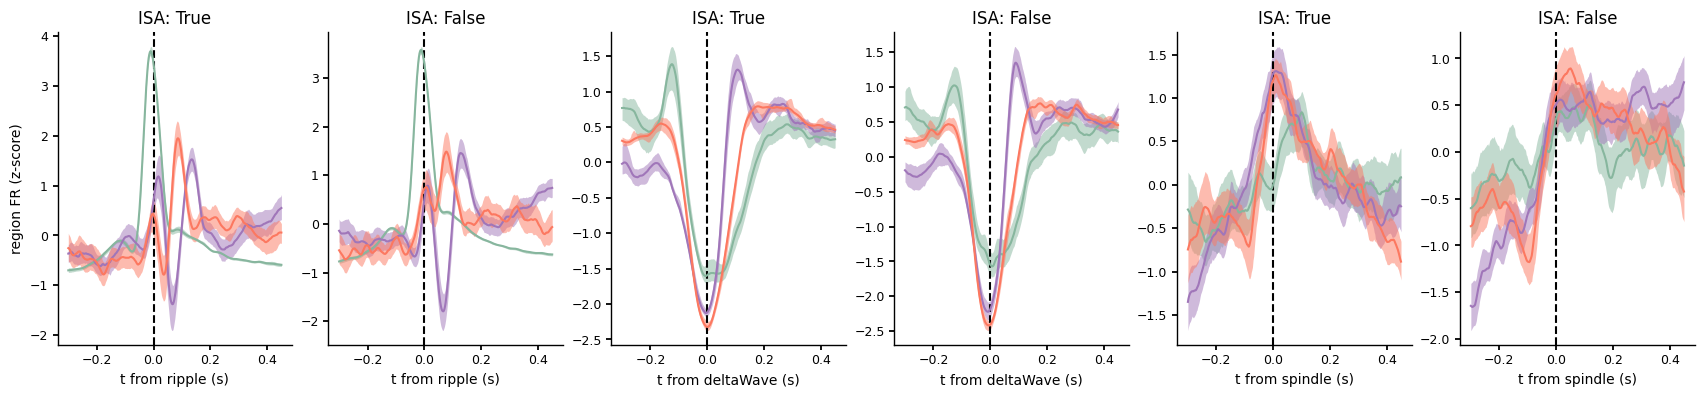

In [100]:
# see averages PETHs by ISA
fig, ax = fma.plotting.makeFigure(n=(1,2*len(peth_isa)),size=(43,10))
for k, n in enumerate(peth_isa):
    for j, isa in enumerate([True,False]):
        i = 2*k + j
        ax[i].set(xlabel=f't from {n[:-1]} (s)',title=f'ISA: {isa}')
        ax[i].axvline(0,color='k',ls='--')
        fr_p = peth_isa[n].sel(isa=isa)
        for r in fr_p['reg'].values:
            if r != 'th':
                fma.plotting.semPlot(fr_p.t,fr_p.sel(reg=r),zscore=2,color=isru.paperColors(r),ax=ax[i])
ax[0].set(ylabel='region FR (z-score)');

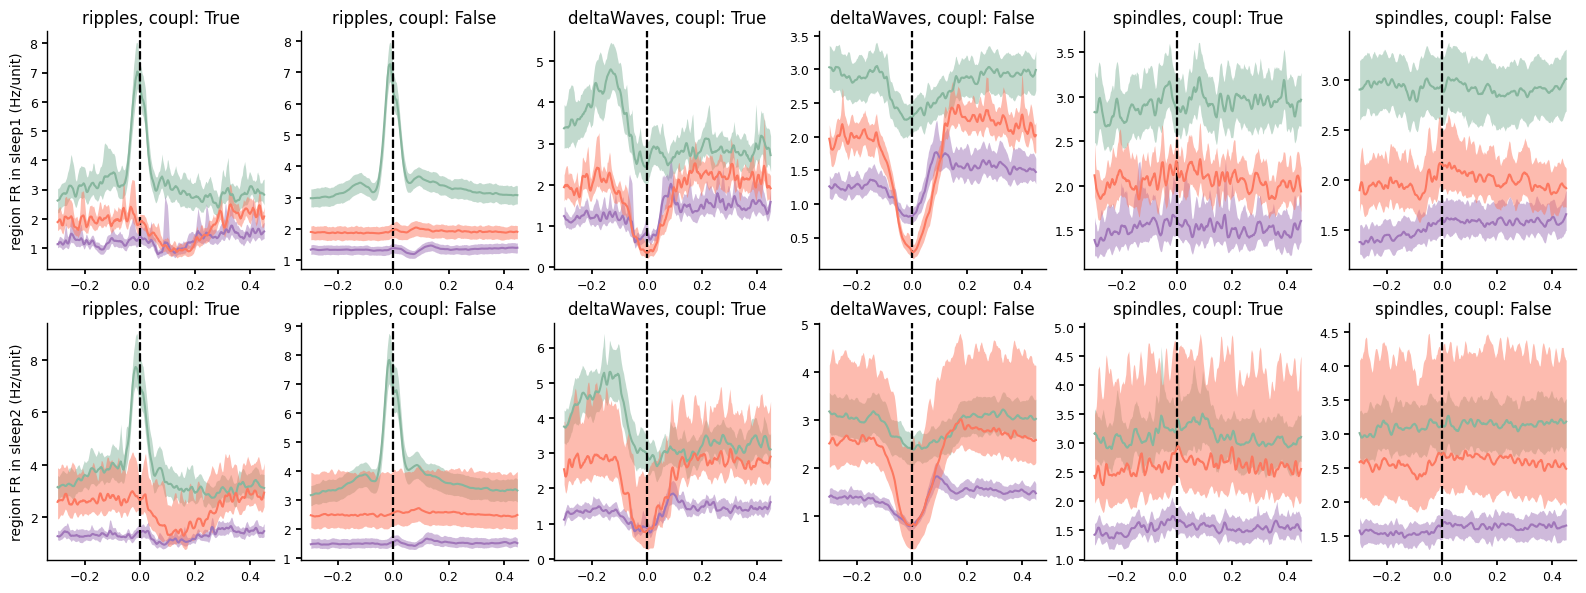

In [14]:
# see epoch-coupling combinations
fig, ax = fma.plotting.makeFigure(n=(2,len(peth_epoch_coupl)*2),size=(40,15))
for i, n in enumerate(peth_epoch_coupl):
    fr_p = peth_epoch_coupl[n]
    for epoch in [1,2]:
        for coupl in [True,False]:
            for r in fr_p['reg'].values:
                if r != 'th':
                    ax[epoch-1,2*i+(not coupl)].set_title(f'{n}, coupl: {coupl}')
                    ax[epoch-1,2*i+(not coupl)].axvline(0,color='k',ls='--')
                    fma.plotting.semPlot(fr_p['t'],fr_p.sel(epoch=epoch,coupl=coupl,reg=r),color=isru.paperColors(r),ax=ax[epoch-1,2*i+(not coupl)])
ax[0,0].set(ylabel='region FR in sleep1 (Hz/unit)'); ax[1,0].set(ylabel='region FR in sleep2 (Hz/unit)');

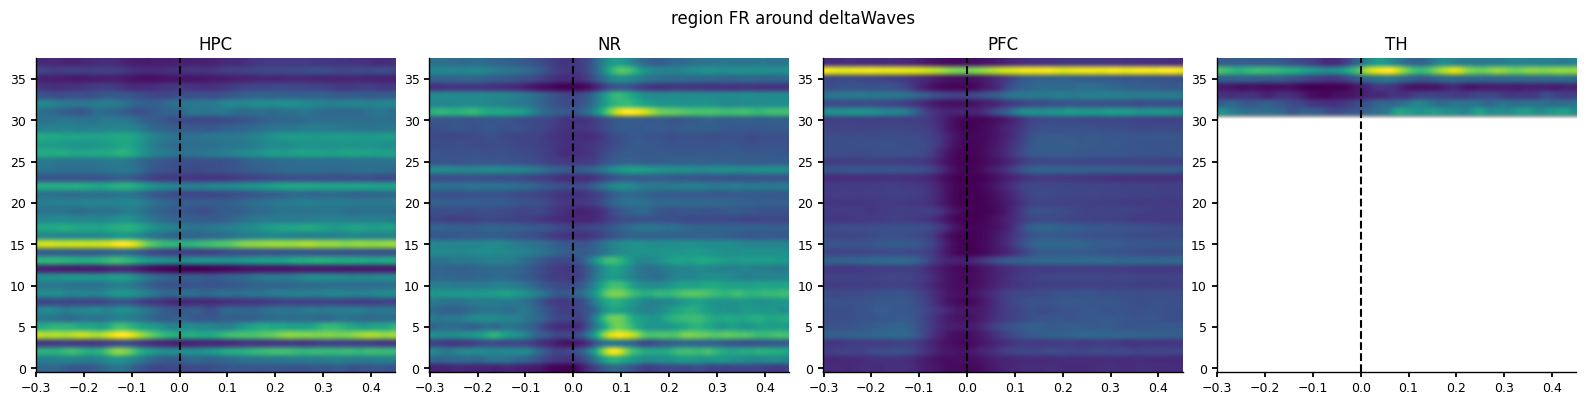

In [102]:
# see delta activity PETH
name = 'deltaWaves'
fr_p = peth_avg[name]
fig, ax = fma.plotting.makeFigure(f'region FR around {name}',n=(1,len(fr_p['reg'])),size=(40,10))
for i, r in enumerate(fr_p['reg'].values):
    ax[i].set_title(r.upper())
    ax[i].axvline(0,color='k',ls='--')
    fma.plotting.plotColorMap(fr_p.sel(reg=r).values,x=fr_p.t,sortby=None,ax=ax[i],zscore=None)

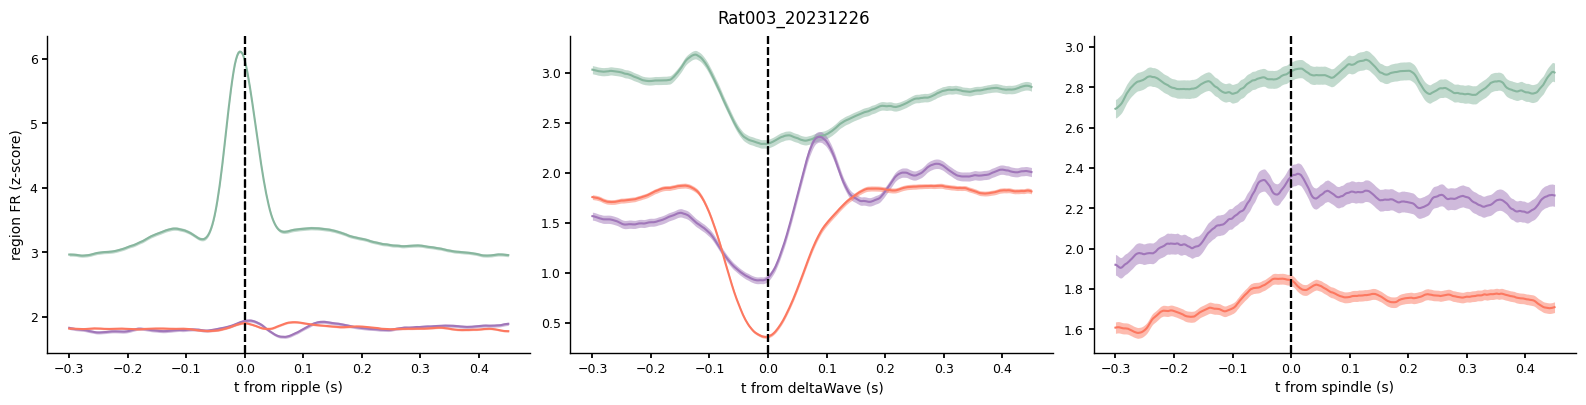

In [24]:
# see delta activity PETH examples
k = 10
base = np.unique(peth_cat['ripples'].base)[k].item()
fig, ax = fma.plotting.makeFigure(base,n=(1,len(peth_avg)),size=(40,10))
for i, n in enumerate(peth_avg):
    fr_p = peth_cat[n].where(peth_cat[n].base==base,drop=True)
    for j, r in enumerate(fr_p['reg'].values):
        ax[i].set(xlabel=f't from {n[:-1]} (s)')
        ax[i].axvline(0,color='k',ls='--')
        fma.plotting.semPlot(fr_p.t,fr_p.sel(reg=r),ax=ax[i],zscore=None,color=isru.paperColors(r))
ax[0].set(ylabel='region FR (z-score)');

In [8]:
# see ripple activity PETH
name = 'ripples'
isa = [True,False]
coupl = [False,True]
valid = xr.DataArray((np.isin(peth_cat[name].isa,isa)) & (np.isin(peth_cat[name].coupl,coupl)),dims='rat')
fr_p = peth_cat[name].where(valid,drop=True)
fig, ax = fma.plotting.makeFigure(f'region FR around {name}, ISA: {isa}, coupled: {coupl}',n=[1,len(fr_p['reg'])],size=[40,10])

for i, r in enumerate(fr_p['reg'].values):
    ax[i].set_title(r)
    ax[i].axvline(0,color='k',ls='--')
    fma.plotting.plotColorMap(fr_p.sel(reg=r).values,sortby=None,ax=ax[i],zscore=None)

ValueError: Dimensions {'rat'} do not exist. Expected one or more of FrozenMappingWarningOnValuesAccess({'t': 351, 'reg': 4, 'event': 128502})

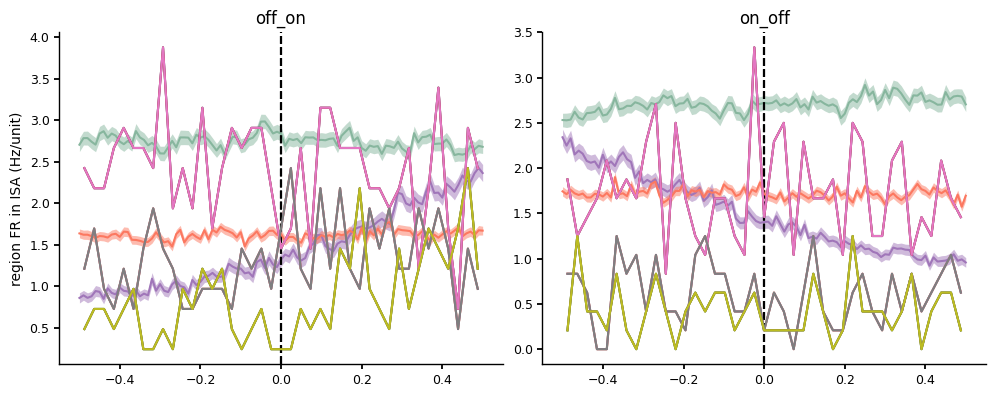

In [39]:
fig, ax = fma.plotting.makeFigure(n=[1,len(peth_isa)],size=[25,10])
for i, (name, fr_p) in enumerate(peth_isa.items()):
    for r in fr_p['reg'].values:
        ax[i].set_title(name)
        ax[i].axvline(0,color='k',ls='--')
        fma.plotting.semPlot(fr_p['t'],fr_p.sel(reg=r),color=isru.paperColors(r),ax=ax[i])
        ax[i].plot(peth_oscill['t'],peth_oscill.sel(tran=name).T*150)
ax[0].set(ylabel='region FR in ISA (Hz/unit)');

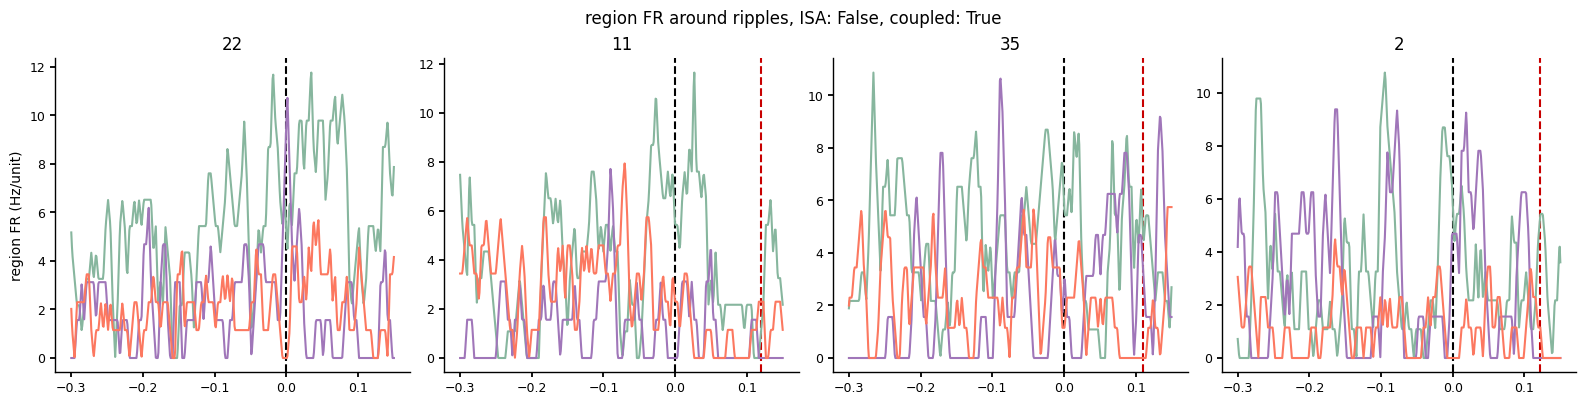

In [70]:
# see example ripples
name = 'ripples'
isa = False
coupl = True
valid = (peth[name].isa==isa) & (peth[name].coupl==coupl)
fig, ax = fma.plotting.makeFigure(f'region FR around {name}, ISA: {isa}, coupled: {coupl}',n=[1,4],size=[40,10])
fr_p = peth[name].where(valid,drop=True)
for j, k in enumerate(np.random.randint(len(fr_p),size=4)):
    ax[j].set_title(k)
    ax[j].axvline(0,color='k',ls='--')
    delt = fma.general.restrict(events['deltaWaves']-events[name][valid][k],fr_p['t'][[0,-1]]).ravel()
    [ax[j].axvline(d,color=isru.paperColors('deltaWaves'),ls='--') for d in delt]
    for r in ['hpc','nr','pfc']:
        ax[j].plot(fr_p['t'],fr_p.sel(reg=r)[k],color=isru.paperColors(r))
ax[0].set(ylabel='region FR (Hz/unit)');

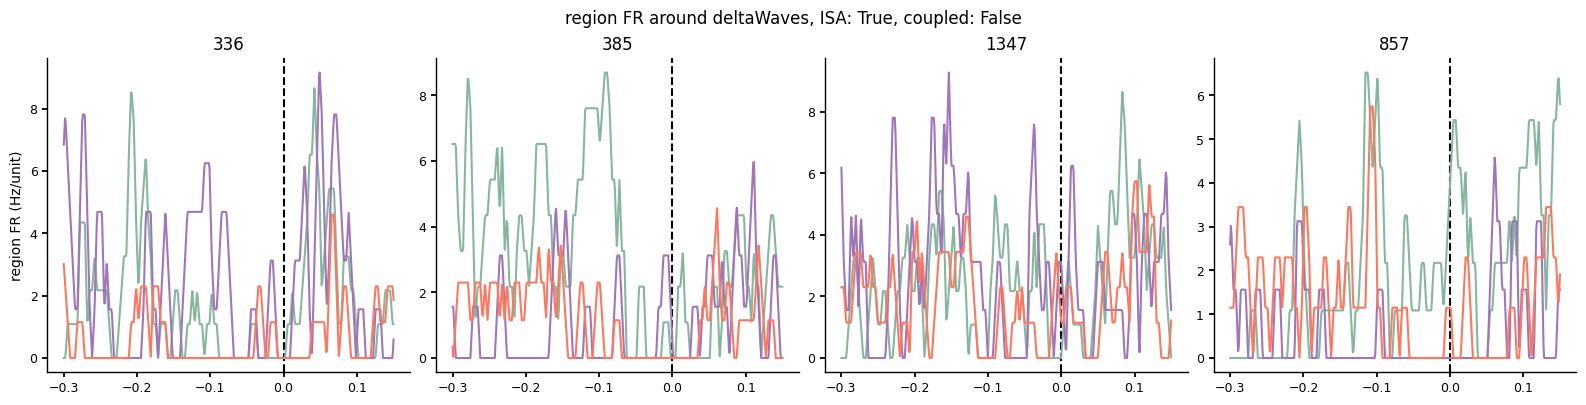

In [73]:
# see example deltas
name = 'deltaWaves'
isa = True
coupl = False
valid = (peth[name].isa==isa) & (peth[name].coupl==coupl)
fig, ax = fma.plotting.makeFigure(f'region FR around {name}, ISA: {isa}, coupled: {coupl}',n=[1,4],size=[40,10])
fr_p = peth[name].where(valid,drop=True)
for j, k in enumerate(np.random.randint(len(fr_p),size=4)):
    ax[j].set_title(k)
    ax[j].axvline(0,color='k',ls='--')
    delt = fma.general.restrict(events['ripples']-events[name][valid][k],fr_p['t'][[0,-1]]).ravel()
    [ax[j].axvline(d,color=isru.paperColors('ripples'),ls='--') for d in delt]
    for r in ['hpc','nr','pfc']:
        ax[j].plot(fr_p['t'],fr_p.sel(reg=r)[k],color=isru.paperColors(r))
ax[0].set(ylabel='region FR (Hz/unit)');